<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [8]:
#!pip install matplotlib
!pip install seaborn 
!pip install tabolite

Looking in indexes: https://repos.tech.orange/artifactory/api/pypi/pythonproxy/simple/, https://repos.tech.orange/artifactory/api/pypi/pythonproxy-cache/simple/
Looking in indexes: https://repos.tech.orange/artifactory/api/pypi/pythonproxy/simple/, https://repos.tech.orange/artifactory/api/pypi/pythonproxy-cache/simple/


ERROR: Could not find a version that satisfies the requirement tabolite (from versions: none)
ERROR: No matching distribution found for tabolite


In [7]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from tabulate import tabulate

ModuleNotFoundError: No module named 'seaborn'

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [17]:
#Importation du fichier population.csv
population = pd.read_csv("C:\Users\FCQC8398\OneDrive - orange.com\Documents\OpenClassrooms\projet4_python\population")

#Importation du fichier dispo_alimentaire.csv

dispo_alimentaire = pd.read_csv("C:\Users\FCQC8398\OneDrive - orange.com\Documents\OpenClassrooms\projet4_python\dispo_alimentaire")

#Importation du fichier aide_alimentaire.csv

aide_alimentaire = pd.read_csv("C:\Users\FCQC8398\OneDrive - orange.com\Documents\OpenClassrooms\projet4_python\aide_alimentaire")

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv("C:\Users\FCQC8398\OneDrive - orange.com\Documents\OpenClassrooms\projet4_python\sous_nutrition")



FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/RGDG7589/OneDrive - orange.com/Documents/Projet_4_OC/DAN-P4-FAO/population.csv'

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print("Le tableau a {} colonnes ".format(population.shape[1]))
#La nature des données dans chacune des colonnes
print(population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
Valeurs_par_colonne=population.count()
print("Nombre de valeurs pour chaque colonne")
print(Valeurs_par_colonne)

Le tableau a 3 colonnes 
Zone       object
Année       int64
Valeur    float64
dtype: object
Nombre de valeurs pour chaque colonne
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [ ]:
#Affichage les 5 premières lignes de la table
print("Les 5 premières lignes du tableau ")
print(population.head())


Les 5 premières lignes du tableau 
          Zone  Année     Valeur
0  Afghanistan   2013  32269.589
1  Afghanistan   2014  33370.794
2  Afghanistan   2015  34413.603
3  Afghanistan   2016  35383.032
4  Afghanistan   2017  36296.113


In [ ]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur']=population['Valeur']*1000
print(population)

             Zone  Année      Valeur
0     Afghanistan   2013  32269589.0
1     Afghanistan   2014  33370794.0
2     Afghanistan   2015  34413603.0
3     Afghanistan   2016  35383032.0
4     Afghanistan   2017  36296113.0
...           ...    ...         ...
1411     Zimbabwe   2014  13586707.0
1412     Zimbabwe   2015  13814629.0
1413     Zimbabwe   2016  14030331.0
1414     Zimbabwe   2017  14236595.0
1415     Zimbabwe   2018  14438802.0

[1416 rows x 3 columns]


In [ ]:
#changement du nom de la colonne Valeur par Population
population=population.rename(columns={'Valeur':'Population'})
print(population)

             Zone  Année  Population
0     Afghanistan   2013  32269589.0
1     Afghanistan   2014  33370794.0
2     Afghanistan   2015  34413603.0
3     Afghanistan   2016  35383032.0
4     Afghanistan   2017  36296113.0
...           ...    ...         ...
1411     Zimbabwe   2014  13586707.0
1412     Zimbabwe   2015  13814629.0
1413     Zimbabwe   2016  14030331.0
1414     Zimbabwe   2017  14236595.0
1415     Zimbabwe   2018  14438802.0

[1416 rows x 3 columns]


In [ ]:
#Affichage les 5 premières lignes de la table pour voir les modifications
print("Les 5 premières lignes du tableau après modification ")
print(population.head())


Les 5 premières lignes du tableau après modification 
          Zone  Année  Population
0  Afghanistan   2013  32269589.0
1  Afghanistan   2014  33370794.0
2  Afghanistan   2015  34413603.0
3  Afghanistan   2016  35383032.0
4  Afghanistan   2017  36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [ ]:
#Consulter le nombre de colonnes

print(dispo_alimentaire.dtypes)

Zone                                                              object
Produit                                                           object
Origine                                                           object
Aliments pour animaux                                            float64
Autres Utilisations                                              float64
Disponibilité alimentaire (Kcal/personne/jour)                   float64
Disponibilité alimentaire en quantité (kg/personne/an)           float64
Disponibilité de matière grasse en quantité (g/personne/jour)    float64
Disponibilité de protéines en quantité (g/personne/jour)         float64
Disponibilité intérieure                                         float64
Exportations - Quantité                                          float64
Importations - Quantité                                          float64
Nourriture                                                       float64
Pertes                                             

In [ ]:
#Affichage les 5 premières lignes de la table
print("Les 5 premières lignes de la table dispo_alimentaire")
print(dispo_alimentaire.head())

Les 5 premières lignes de la table dispo_alimentaire
          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    NaN   
1  Afghanistan        Agrumes, Autres  vegetale                    NaN   
2  Afghanistan  Aliments pour enfants  vegetale                    NaN   
3  Afghanistan                 Ananas  vegetale                    NaN   
4  Afghanistan                Bananes  vegetale                    NaN   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  NaN                                             5.0   
1                  NaN                                             1.0   
2                  NaN                                             1.0   
3                  NaN                                             0.0   
4                  NaN                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)

In [ ]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire=dispo_alimentaire.fillna(0)
print(dispo_alimentaire)


               Zone                Produit   Origine  Aliments pour animaux  \
0       Afghanistan       Abats Comestible   animale                    0.0   
1       Afghanistan        Agrumes, Autres  vegetale                    0.0   
2       Afghanistan  Aliments pour enfants  vegetale                    0.0   
3       Afghanistan                 Ananas  vegetale                    0.0   
4       Afghanistan                Bananes  vegetale                    0.0   
...             ...                    ...       ...                    ...   
15600  Îles Salomon       Viande de Suides   animale                    0.0   
15601  Îles Salomon    Viande de Volailles   animale                    0.0   
15602  Îles Salomon          Viande, Autre   animale                    0.0   
15603  Îles Salomon                    Vin  vegetale                    0.0   
15604  Îles Salomon         Épices, Autres  vegetale                    0.0   

       Autres Utilisations  Disponibilité alimentai

In [ ]:
dispo_alimentaire=pd.DataFrame(dispo_alimentaire)
print(dispo_alimentaire)

0         animale
1        vegetale
2        vegetale
3        vegetale
4        vegetale
           ...   
92491     animale
92492     animale
92493     animale
92494    vegetale
92495    vegetale
Name: Origine, Length: 92496, dtype: object


In [ ]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
col = ['Aliments pour animaux', 'Autres Utilisations', 'Disponibilité intérieure', 'Nourriture', 'Pertes', 'Semences', 'Traitement']
dispo_alimentaire.loc[:, col] *= 1000000
#print(dispo_alimentaire)


In [ ]:
#Affichage les 5 premières lignes de la table
print(dispo_alimentaire)



               Zone                Produit   Origine  Aliments pour animaux  \
0       Afghanistan       Abats Comestible   animale                    0.0   
1       Afghanistan        Agrumes, Autres  vegetale                    0.0   
2       Afghanistan  Aliments pour enfants  vegetale                    0.0   
3       Afghanistan                 Ananas  vegetale                    0.0   
4       Afghanistan                Bananes  vegetale                    0.0   
...             ...                    ...       ...                    ...   
15600  Îles Salomon       Viande de Suides   animale                    0.0   
15601  Îles Salomon    Viande de Volailles   animale                    0.0   
15602  Îles Salomon          Viande, Autre   animale                    0.0   
15603  Îles Salomon                    Vin  vegetale                    0.0   
15604  Îles Salomon         Épices, Autres  vegetale                    0.0   

       Autres Utilisations  Disponibilité alimentai

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print(aide_alimentaire.dtypes)

Pays bénéficiaire    object
Année                 int64
Produit              object
Valeur                int64
dtype: object


In [ ]:
#Affichage les 5 premières lignes de la table
print("Les 5 premières lignes de la table")
print(aide_alimentaire.head())

Les 5 premières lignes de la table
  Pays bénéficiaire  Année              Produit  Valeur
0       Afghanistan   2013  Autres non-céréales     682
1       Afghanistan   2014  Autres non-céréales     335
2       Afghanistan   2013         Blé et Farin   39224
3       Afghanistan   2014         Blé et Farin   15160
4       Afghanistan   2013             Céréales   40504


In [ ]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire=aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'})
print(aide_alimentaire)

             Zone  Année                   Produit  Valeur
0     Afghanistan   2013       Autres non-céréales     682
1     Afghanistan   2014       Autres non-céréales     335
2     Afghanistan   2013              Blé et Farin   39224
3     Afghanistan   2014              Blé et Farin   15160
4     Afghanistan   2013                  Céréales   40504
...           ...    ...                       ...     ...
1470     Zimbabwe   2015  Mélanges et préparations      96
1471     Zimbabwe   2013              Non-céréales    5022
1472     Zimbabwe   2014              Non-céréales    2310
1473     Zimbabwe   2015              Non-céréales     306
1474     Zimbabwe   2013                Riz, total      64

[1475 rows x 4 columns]


In [ ]:
aide_alimentaire['Valeur']=aide_alimentaire['Valeur']*1000
print(aide_alimentaire['Valeur'].astype(str) + 'kg')


0         682000kg
1         335000kg
2       39224000kg
3       15160000kg
4       40504000kg
           ...    
1470       96000kg
1471     5022000kg
1472     2310000kg
1473      306000kg
1474       64000kg
Name: Valeur, Length: 1475, dtype: object


In [ ]:
#Affichage les 5 premières lignes de la table
print(aide_alimentaire)


             Zone  Année                   Produit    Valeur
0     Afghanistan   2013       Autres non-céréales    682000
1     Afghanistan   2014       Autres non-céréales    335000
2     Afghanistan   2013              Blé et Farin  39224000
3     Afghanistan   2014              Blé et Farin  15160000
4     Afghanistan   2013                  Céréales  40504000
...           ...    ...                       ...       ...
1470     Zimbabwe   2015  Mélanges et préparations     96000
1471     Zimbabwe   2013              Non-céréales   5022000
1472     Zimbabwe   2014              Non-céréales   2310000
1473     Zimbabwe   2015              Non-céréales    306000
1474     Zimbabwe   2013                Riz, total     64000

[1475 rows x 4 columns]


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print(sous_nutrition.dtypes)

Zone      object
Année     object
Valeur    object
dtype: object


In [ ]:
#Afficher les 5 premières lignes de la table
print(sous_nutrition.head())

          Zone      Année Valeur
0  Afghanistan  2012-2014    8.6
1  Afghanistan  2013-2015    8.8
2  Afghanistan  2014-2016    8.9
3  Afghanistan  2015-2017    9.7
4  Afghanistan  2016-2018   10.5


#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])
print(sous_nutrition)

In [ ]:
#Conversion de la colonne sous nutrition en numérique
#sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])


In [ ]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['Valeur']= pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')
#Puis remplacement des NaN en 0
sous_nutrition=sous_nutrition.fillna(0)
print(sous_nutrition)

             Zone      Année  Valeur
0     Afghanistan  2012-2014     8.6
1     Afghanistan  2013-2015     8.8
2     Afghanistan  2014-2016     8.9
3     Afghanistan  2015-2017     9.7
4     Afghanistan  2016-2018    10.5
...           ...        ...     ...
1213     Zimbabwe  2013-2015     0.0
1214     Zimbabwe  2014-2016     0.0
1215     Zimbabwe  2015-2017     0.0
1216     Zimbabwe  2016-2018     0.0
1217     Zimbabwe  2017-2019     0.0

[1218 rows x 3 columns]


In [ ]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition=sous_nutrition.rename(columns={'Valeur':'sous_nutrition'})
print(sous_nutrition)

             Zone      Année  sous_nutrition
0     Afghanistan  2012-2014             8.6
1     Afghanistan  2013-2015             8.8
2     Afghanistan  2014-2016             8.9
3     Afghanistan  2015-2017             9.7
4     Afghanistan  2016-2018            10.5
...           ...        ...             ...
1213     Zimbabwe  2013-2015             0.0
1214     Zimbabwe  2014-2016             0.0
1215     Zimbabwe  2015-2017             0.0
1216     Zimbabwe  2016-2018             0.0
1217     Zimbabwe  2017-2019             0.0

[1218 rows x 3 columns]


In [ ]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition']=sous_nutrition['sous_nutrition']*1000000
print(sous_nutrition)

             Zone      Année  sous_nutrition
0     Afghanistan  2012-2014       8600000.0
1     Afghanistan  2013-2015       8800000.0
2     Afghanistan  2014-2016       8900000.0
3     Afghanistan  2015-2017       9700000.0
4     Afghanistan  2016-2018      10500000.0
...           ...        ...             ...
1213     Zimbabwe  2013-2015             0.0
1214     Zimbabwe  2014-2016             0.0
1215     Zimbabwe  2015-2017             0.0
1216     Zimbabwe  2016-2018             0.0
1217     Zimbabwe  2017-2019             0.0

[1218 rows x 3 columns]


In [ ]:
#Afficher les 5 premières lignes de la table
print(sous_nutrition.head())

          Zone      Année  sous_nutrition
0  Afghanistan  2012-2014       8600000.0
1  Afghanistan  2013-2015       8800000.0
2  Afghanistan  2014-2016       8900000.0
3  Afghanistan  2015-2017       9700000.0
4  Afghanistan  2016-2018      10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [ ]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
pop_nut=pd.merge(
    population.loc[population["Année"] == 2017,['Zone','Population','Année']],
    sous_nutrition.loc[sous_nutrition["Année"] == "2016-2018",['Zone','sous_nutrition','Année']],
    on="Zone", suffixes=["_p", "_sn"]
)




In [ ]:
#Affichage du dataset
print(pop_nut)

                                       Zone  Population  Année_p  \
0                               Afghanistan  36296113.0     2017   
1                            Afrique du Sud  57009756.0     2017   
2                                   Albanie   2884169.0     2017   
3                                   Algérie  41389189.0     2017   
4                                 Allemagne  82658409.0     2017   
..                                      ...         ...      ...   
198  Venezuela (République bolivarienne du)  29402484.0     2017   
199                                Viet Nam  94600648.0     2017   
200                                   Yémen  27834819.0     2017   
201                                  Zambie  16853599.0     2017   
202                                Zimbabwe  14236595.0     2017   

     sous_nutrition   Année_sn  
0        10500000.0  2016-2018  
1         3100000.0  2016-2018  
2          100000.0  2016-2018  
3         1300000.0  2016-2018  
4               0.

In [ ]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
somme=pop_nut['sous_nutrition'].sum()
print("Le nombre de personnes en état de sous-nutrition:", somme)
#Proportion sous_nutrition par rapoort à la pop totale 
pop_totale= pop_nut['Population'].sum()
proportion= ((somme / pop_totale)*100).round(2)
print(f"La proportion de personnes en état de sous nutrition: {proportion} %")


Le nombre de personnes en état de sous-nutrition: 535700000.0
La proportion de personnes en état de sous nutrition: 7.1 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [ ]:
#Combien mange en moyenne un être humain ? Source => https://www.vidal.fr/sante/nutrition/equilibre-alimentaire-adulte/recommandations-nutritionnelles-adulte.html#:~:text=La%20quantit%C3%A9%20de%20calories%20n%C3%A9cessaire,jour%2C%20selon%20l%27activit%C3%A9.
consommation_moyenne= 2250

In [ ]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
#leftJoin pour obtenir toutes les lignes de dispo_alimentaire en rajoutant la colonne population
dispo_alimentaire=pd.merge(population, dispo_alimentaire,
    on="Zone")


In [ ]:
#Affichage du nouveau dataframe
print(dispo_alimentaire)

              Zone  Année  Population                Produit   Origine  \
0      Afghanistan   2013  32269589.0       Abats Comestible   animale   
1      Afghanistan   2013  32269589.0        Agrumes, Autres  vegetale   
2      Afghanistan   2013  32269589.0  Aliments pour enfants  vegetale   
3      Afghanistan   2013  32269589.0                 Ananas  vegetale   
4      Afghanistan   2013  32269589.0                Bananes  vegetale   
...            ...    ...         ...                    ...       ...   
92491     Zimbabwe   2018  14438802.0       Viande de Suides   animale   
92492     Zimbabwe   2018  14438802.0    Viande de Volailles   animale   
92493     Zimbabwe   2018  14438802.0          Viande, Autre   animale   
92494     Zimbabwe   2018  14438802.0                    Vin  vegetale   
92495     Zimbabwe   2018  14438802.0         Épices, Autres  vegetale   

       Aliments pour animaux  Autres Utilisations  \
0                        0.0                  0.0   
1    

In [ ]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_2017= dispo_alimentaire[dispo_alimentaire['Année']==2017]
dispo_2017['dispo_kcal'] = dispo_2017['Population'] * dispo_alimentaire['Disponibilité alimentaire (Kcal/personne/jour)'] *365
print(dispo_2017['dispo_kcal'])

 

240      6.624041e+10
241      1.324808e+10
242      1.324808e+10
243      0.000000e+00
244      5.299232e+10
             ...     
92399    1.247126e+11
92400    8.833807e+10
92401    3.637450e+10
92402    5.196357e+09
92403    5.196357e+09
Name: dispo_kcal, Length: 15416, dtype: float64


C:\Users\RGDG7589\AppData\Local\Temp\1\ipykernel_16844\3741447550.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dispo_2017['dispo_kcal'] = dispo_2017['Population'] * dispo_alimentaire['Disponibilité alimentaire (Kcal/personne/jour)'] *365


In [ ]:
#Calcul du nombre d'humains pouvant être nourris
som_k_cal=dispo_2017['dispo_kcal'].sum()
Nbre_personnes= (som_k_cal/(consommation_moyenne *365)).round(0)
print("Le nombre de personnes pouvant être nourries:", Nbre_personnes)
prop=((Nbre_personnes/pop_totale)*100).round(2)
print(f"Les personnes pouvant être nourries en proportion {prop}, %")
#IL FAUT CALCULER COMBIEN UNE PERSONNE CONSOMME PAR AN

Le nombre de personnes pouvant être nourries: 9297326501.0
Les personnes pouvant être nourries en proportion 123.24, %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [ ]:
#Transfert des données avec les végétaux dans un nouveau dataframe
vegetaux=dispo_2017[dispo_2017['Origine']=='vegetale']
print(vegetaux)

              Zone  Année  Population                Produit   Origine  \
241    Afghanistan   2017  36296113.0        Agrumes, Autres  vegetale   
242    Afghanistan   2017  36296113.0  Aliments pour enfants  vegetale   
243    Afghanistan   2017  36296113.0                 Ananas  vegetale   
244    Afghanistan   2017  36296113.0                Bananes  vegetale   
246    Afghanistan   2017  36296113.0                  Bière  vegetale   
...            ...    ...         ...                    ...       ...   
92394     Zimbabwe   2017  14236595.0                 Sésame  vegetale   
92395     Zimbabwe   2017  14236595.0                    Thé  vegetale   
92396     Zimbabwe   2017  14236595.0                Tomates  vegetale   
92402     Zimbabwe   2017  14236595.0                    Vin  vegetale   
92403     Zimbabwe   2017  14236595.0         Épices, Autres  vegetale   

       Aliments pour animaux  Autres Utilisations  \
241                      0.0                  0.0   
242  

In [ ]:
#Calcul du nombre de kcal disponible pour les végétaux
#kcal_veg =vegetaux.groupby(['Zone','Année','dispo_kcal']).sum()
som_k_cal_vegetaux=vegetaux['dispo_kcal'].sum()
print("Le nombre de kcal disponible pour les végétaux:", som_k_cal_vegetaux)



Le nombre de kcal disponible pour les végétaux: 6300178937197865.0


In [ ]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
Nbre_personnes_vegetaux= (som_k_cal_vegetaux/(consommation_moyenne *365)).round(0).astype(int)
print("Le nombre de personnes pouvant être nourries par les végétaux:", Nbre_personnes_vegetaux)
prop=((Nbre_personnes_vegetaux/pop_totale)*100).round(2)
print(f"Les personnes pouvant être nourries par les végétaux en proportion {prop} %")

Le nombre de personnes pouvant être nourries par les végétaux: 7671450761
Les personnes pouvant être nourries par les végétaux en proportion 101.69 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [ ]:
#Calcul de la disponibilité totale
dispo_totale= (dispo_2017['Disponibilité intérieure']).sum()
print("La disponibilité totale:",dispo_totale)


La disponibilité totale: 9733927000000.0


In [ ]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, semences, traitements et autres utilisations 
colonne=['Aliments pour animaux','Pertes','Nourriture', 'Semences', 'Traitement', 'Autres Utilisations']
#if not dispo_2017.empty:
total_sum = dispo_2017[colonne].sum().sum() 
proportions = {col: 0 for col in colonne} #initialisation pour stocker les valeurs de proportion
for col in colonne:
        proportions[col] = (dispo_2017[col].sum() / dispo_totale) * 100 if total_sum > 0 else 0

for col in colonne:
        print("Proportion de {} : {:.2f} %".format(col, proportions[col]))

    #Il faut multiplier dispo_alimentaire[['Aliments pour animaux','Nourriture','Pertes','Nourriture', 'Semences', 'Traitement', 'Autres Utilisations']])*1000000
 

Proportion de Aliments pour animaux : 13.23 %
Proportion de Pertes : 4.65 %
Proportion de Nourriture : 49.37 %
Proportion de Semences : 1.58 %
Proportion de Traitement : 22.45 %
Proportion de Autres Utilisations : 8.82 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [ ]:
#Création d'une liste avec toutes les variables
variables=list(dispo_2017.columns)
print(variables)



NameError: name 'dispo_2017' is not defined

In [ ]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
liste_cereales = ['Blé', 'Riz','Orge', 'Maïs', 'Seigle',
                  'Avoine', 'Millet', 'Sorgho', 'Céréales', 'Autres']
df_cereales= dispo_2017[dispo_2017['Produit'].isin(liste_cereales)]
print(df_cereales)



                 Zone  Année  Population Produit   Origine  \
247       Afghanistan   2017  36296113.0     Blé  vegetale   
272       Afghanistan   2017  36296113.0    Maïs  vegetale   
274       Afghanistan   2017  36296113.0  Millet  vegetale   
280       Afghanistan   2017  36296113.0    Orge  vegetale   
747    Afrique du Sud   2017  57009756.0  Avoine  vegetale   
...               ...    ...         ...     ...       ...   
92360        Zimbabwe   2017  14236595.0    Maïs  vegetale   
92362        Zimbabwe   2017  14236595.0  Millet  vegetale   
92370        Zimbabwe   2017  14236595.0    Orge  vegetale   
92388        Zimbabwe   2017  14236595.0  Seigle  vegetale   
92390        Zimbabwe   2017  14236595.0  Sorgho  vegetale   

       Aliments pour animaux  Autres Utilisations  \
247                      0.0                  0.0   
272              200000000.0                  0.0   
274                      0.0                  0.0   
280              360000000.0               

In [ ]:
#Affichage de la proportion d'alimentation animale
#calculer la dispo totale  pour df_cereales
#origine_animal=dispo_2017[dispo_2017['Origine']=='animale']
#print(origine_animal)
total_ani=(df_cereales['Aliments pour animaux']).sum()
dispo_cereales=df_cereales['Disponibilité intérieure'].sum()
proportion_animale=(total_ani *100/dispo_cereales).round(2)
print(f"La proportion d'alimentation animale: {proportion_animale} %" )


#print("Proportion d'alimentation animale :", "{:.2f}".format(df_cereales['Aliments pour animaux'].sum()*100/df_cereales['Disponibilité intérieure'].sum()), "%")
#Proportion d'alimentation animale : 36.14 %


La proportion d'alimentation animale: 43.03 %


In [ ]:
#Affichage de la proportion d'alimentation humainetotal_ani=(df_cereales['Aliments pour animaux']).sum()
total_nourriture=df_cereales['Nourriture'].sum()
proportion_nourriture=((total_nourriture/dispo_cereales) *100).round(2)
print(f"La proportion d'alimentation animale: {proportion_nourriture} %" )
#print("Proportion d'alimentation humaine:", "{:.2f}".format(df_cereales['Nourriture'].sum()*100/df_cereales['Disponibilité intérieure'].sum()), "%")

#Proportion d'alimentation humaine : 42.91 %"""


La proportion d'alimentation animale: 34.03 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [ ]:
#Création de la colonne proportion par pays
pop_nut['proportion_sous_nut']= ( pop_nut['sous_nutrition'] / pop_nut['Population']) *100
print(pop_nut)

                                       Zone  Population  sous_nutrition  \
0                               Afghanistan  36296113.0      10500000.0   
1                            Afrique du Sud  57009756.0       3100000.0   
2                                   Albanie   2884169.0        100000.0   
3                                   Algérie  41389189.0       1300000.0   
4                                 Allemagne  82658409.0             0.0   
..                                      ...         ...             ...   
198  Venezuela (République bolivarienne du)  29402484.0       8000000.0   
199                                Viet Nam  94600648.0       6500000.0   
200                                   Yémen  27834819.0             0.0   
201                                  Zambie  16853599.0             0.0   
202                                Zimbabwe  14236595.0             0.0   

     proportion_sous_nut  
0              28.928718  
1               5.437666  
2               3.

In [ ]:
#affichage après trie des 10 pires pays
df_sorted=pop_nut.sort_values(by='sous_nutrition', ascending=False)
top_10_pays= df_sorted.head(10)
print(top_10_pays[['Zone','Année_p','sous_nutrition']])


                                           Zone  Année_p  sous_nutrition
84                                         Inde     2017     190100000.0
136                                    Pakistan     2017      24800000.0
85                                    Indonésie     2017      23600000.0
128                                     Nigéria     2017      22800000.0
16                                   Bangladesh     2017      21500000.0
61                                     Éthiopie     2017      21100000.0
144                                 Philippines     2017      15700000.0
158                 République-Unie de Tanzanie     2017      13400000.0
157  République populaire démocratique de Corée     2017      12000000.0
96                                        Kenya     2017      11900000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [ ]:
#calcul du total de l'aide alimentaire par pays
total_par_pays=aide_alimentaire.groupby('Zone')['Valeur'].sum()
print(total_par_pays)

Zone
Afghanistan     185452000
Algérie          81114000
Angola            5014000
Bangladesh      348188000
Bhoutan           2666000
                  ...    
Zambie            3026000
Zimbabwe         62570000
Égypte            1122000
Équateur          1362000
Éthiopie       1381294000
Name: Valeur, Length: 76, dtype: int64


In [ ]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
top_10=total_par_pays.sort_values(ascending=False).head(10)
print(top_10)

Zone
République arabe syrienne           1858943000
Éthiopie                            1381294000
Yémen                               1206484000
Soudan du Sud                        695248000
Soudan                               669784000
Kenya                                552836000
Bangladesh                           348188000
Somalie                              292678000
République démocratique du Congo     288502000
Niger                                276344000
Name: Valeur, dtype: int64


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [ ]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
aide= aide_alimentaire[['Zone','Année','Valeur']]
df_aide= aide.groupby(['Zone','Année'])['Valeur'].sum()
print(df_aide)

Zone         Année
Afghanistan  2013     128238000
             2014      57214000
Algérie      2013      35234000
             2014      18980000
             2015      17424000
                        ...    
Égypte       2013       1122000
Équateur     2013       1362000
Éthiopie     2013     591404000
             2014     586624000
             2015     203266000
Name: Valeur, Length: 228, dtype: int64


In [ ]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top_5_pays=total_par_pays.sort_values(ascending=False).head(5)
top_5_pays_list=top_5_pays.index.to_list()
print(top_5_pays_list)

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [ ]:
#On filtre sur le dataframe avec notre liste
aide_alimentaire_top5=aide_alimentaire[aide_alimentaire['Zone'].isin(top_5_pays_list)]
print(aide_alimentaire_top5)

          Zone  Année              Produit     Valeur
354   Éthiopie   2013  Autres non-céréales     170000
355   Éthiopie   2014  Autres non-céréales     466000
356   Éthiopie   2015  Autres non-céréales     244000
357   Éthiopie   2013         Blé et Farin  181066000
358   Éthiopie   2014         Blé et Farin  178646000
...        ...    ...                  ...        ...
1447     Yémen   2015           Riz, total    1797000
1448     Yémen   2013         Sucre, total     161000
1449     Yémen   2014         Sucre, total      81000
1450     Yémen   2015         Sucre, total    7617000
1451     Yémen   2016         Sucre, total    2675000

[155 rows x 4 columns]


In [ ]:
# Affichage des pays avec l'aide alimentaire par année
aide_par_annee=aide_alimentaire_top5.groupby(['Zone','Année'])['Valeur'].sum()
print(aide_par_annee)

Zone                       Année
République arabe syrienne  2013     563566000
                           2014     651870000
                           2015     524949000
                           2016     118558000
Soudan                     2013     330230000
                           2014     321904000
                           2015      17650000
Soudan du Sud              2013     196330000
                           2014     450610000
                           2015      48308000
Yémen                      2013     264764000
                           2014     103840000
                           2015     372306000
                           2016     465574000
Éthiopie                   2013     591404000
                           2014     586624000
                           2015     203266000
Name: Valeur, dtype: int64


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [ ]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pays= dispo_alimentaire.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum()
print(dispo_par_pays)

Zone
Afghanistan              1.252200e+10
Afrique du Sud           1.812000e+10
Albanie                  1.912800e+10
Algérie                  1.975800e+10
Allemagne                2.101800e+10
                             ...     
Émirats arabes unis      1.965000e+10
Équateur                 1.407600e+10
États-Unis d'Amérique    2.209200e+10
Éthiopie                 1.277400e+10
Îles Salomon             1.429800e+10
Name: Disponibilité alimentaire (Kcal/personne/jour), Length: 172, dtype: float64


In [ ]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
#dispo_par_pers=dispo_par_pays/dispo_alimentaire['Population']
dispo_par_pers10=dispo_par_pays.sort_values().head(10)
print(dispo_par_pers10)

Zone
République centrafricaine                     1.127400e+10
Zambie                                        1.154400e+10
Madagascar                                    1.233600e+10
Afghanistan                                   1.252200e+10
Haïti                                         1.253400e+10
République populaire démocratique de Corée    1.255800e+10
Tchad                                         1.265400e+10
Zimbabwe                                      1.267800e+10
Ouganda                                       1.275600e+10
Timor-Leste                                   1.277400e+10
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [ ]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
dispo_pers10=dispo_par_pays.sort_values(ascending=False).head(10)
print(dispo_pers10)

Zone
Autriche                 2.262000e+10
Belgique                 2.242200e+10
Turquie                  2.224800e+10
États-Unis d'Amérique    2.209200e+10
Israël                   2.166000e+10
Irlande                  2.161200e+10
Italie                   2.146800e+10
Luxembourg               2.124000e+10
Égypte                   2.110800e+10
Allemagne                2.101800e+10
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [ ]:
#création d'un dataframe avec uniquement la Thaïlande 
sous_nut_thai=sous_nutrition[sous_nutrition['Zone']=='Thaïlande']
print(sous_nut_thai)


           Zone      Année  sous_nutrition
1110  Thaïlande  2012-2014       6200000.0
1111  Thaïlande  2013-2015       6000000.0
1112  Thaïlande  2014-2016       5900000.0
1113  Thaïlande  2015-2017       6000000.0
1114  Thaïlande  2016-2018       6200000.0
1115  Thaïlande  2017-2019       6500000.0


In [ ]:
#Calcul de la sous nutrition en Thaïlande
total_thai= sous_nut_thai['sous_nutrition'].sum()
print("La sous nutrition en Thaïlande", total_thai)


La sous nutrition en Thaïlande 36800000.0


In [ ]:
# On calcule la proportion exportée en fonction de la proportion
tot_aide = aide_alimentaire['Valeur'].sum()
#print(tot_aide)
proportion_exportée=(tot_aide/dispo_totale) *100
print(proportion_exportée)


0.018895938230616825


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [ ]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être 
#le plus en difficulté au niveau alimentaire"

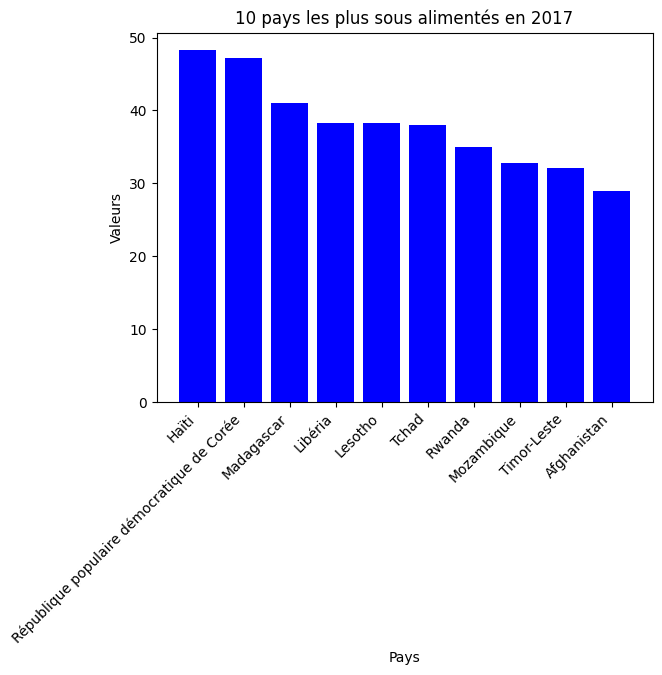

In [ ]:
#Histogramme qui représente les 10 pays les plus sous alimentés en proportion
df_sorted=pop_nut.sort_values(by='proportion_sous_nut', ascending=False)
top_10_pays= df_sorted.head(10)
Pays=top_10_pays['Zone']
Valeurs= top_10_pays['proportion_sous_nut']
plt.xticks(rotation=45, ha='right')
plt.bar(Pays,Valeurs, color='blue')
plt.title('10 pays les plus sous alimentés en 2017')
plt.xlabel('Pays')
plt.ylabel('Valeurs')
plt.show()


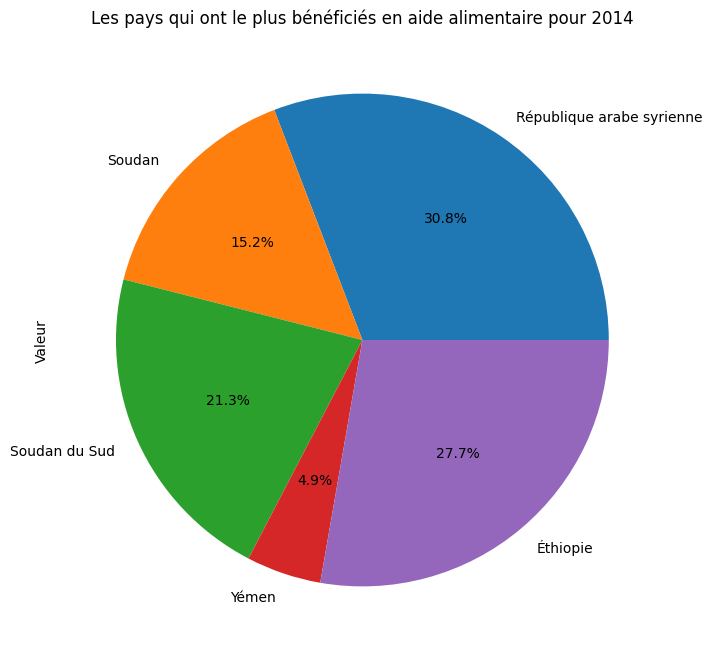

In [ ]:
#print(df_cereales.head())
an= 2014

val=aide_alimentaire_top5[aide_alimentaire_top5['Année'] == an].groupby('Zone')['Valeur'].sum()
val.plot(kind='pie', figsize=(8, 8),autopct='%1.1f%%')
plt.title(f'Les pays qui ont le plus bénéficiés en aide alimentaire pour {an}')
plt.show()


